In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from csv_reader import read_csv
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

In [2]:
def plot_losses(data_paths, xlim=None, ylim=None, thresh=2000):
    for dp in data_paths:
        fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharey=True)

        for i in range(2):
            axs[i].grid(zorder=0, linestyle='--', linewidth=0.5, alpha=0.7)
            axs[i].set_axisbelow(True)
            axs[i].yaxis.set_major_locator(MultipleLocator(1000))  # grid every 1.0 on y-axis
        
        o = read_csv(os.path.join('sims_out', dp, 'train_data.csv'), read_header=False)
        losses = np.array(o.iloc[:, 1])
        axs[0].scatter(np.arange(len(losses)), losses, s=1, c='black', zorder=1)
        axs[0].set_ylim(0, 10000)
        if xlim is not None:
            axs[0].set_xlim(*xlim)
        if ylim is not None:
            axs[0].set_ylim(*ylim)

        o = read_csv(os.path.join('sims_out', dp, 'test_data.csv'), read_header=False)
        x = np.array(o.iloc[:, 0])
        losses_test = np.array(o.iloc[:, 1])
        axs[1].scatter(x, losses_test, s=1, c='black', zorder=1)
        axs[1].set_ylim(0, 10000)
        if xlim is not None:
            axs[1].set_xlim(*xlim)
        if ylim is not None:
            axs[1].set_ylim(*ylim)

        if (losses_test < thresh).any():
            print(dp)

        axs[0].set_ylabel('Loss')
        axs[0].set_xlabel('Epochs')
            
        format_plot(axs)

# 2D results

### 2D network, 300ms integration, no heterogeneity

In [3]:
data_paths = [
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:42:48.164001_run_000850',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:42:53.695039_run_000851',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:42:53.695044_run_000852',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:42:53.695038_run_000853',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:42:53.695043_run_000854',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:42:53.695043_run_000855',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:42:52.783976_run_000856',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:42:52.783974_run_000857',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:42:52.783974_run_000858',
    '2D_short_reverted_time_0.3_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:42:52.783976_run_000859',
]

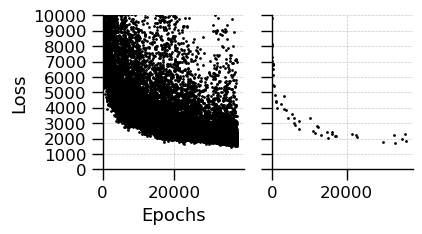

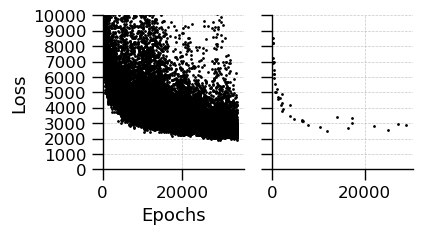

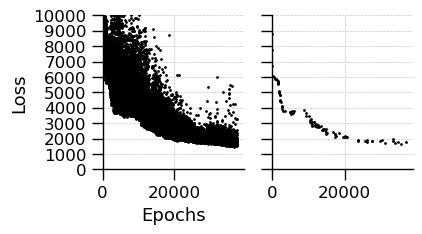

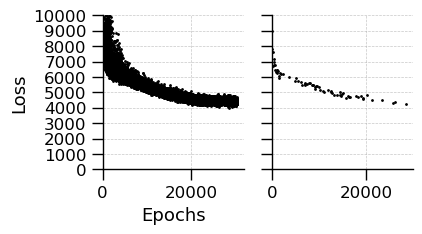

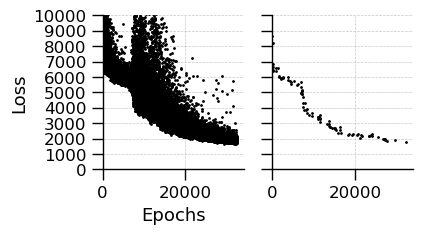

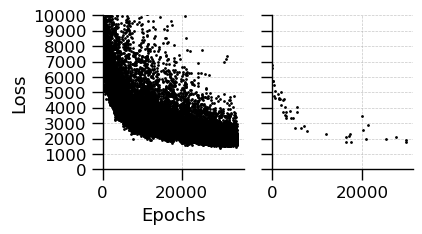

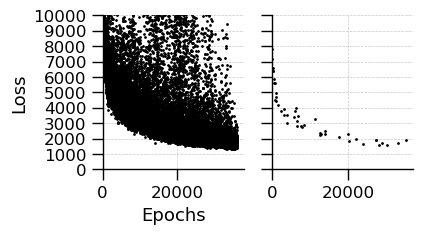

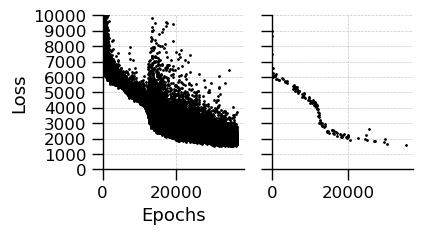

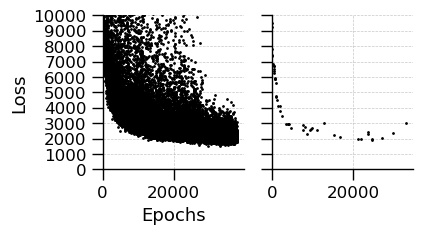

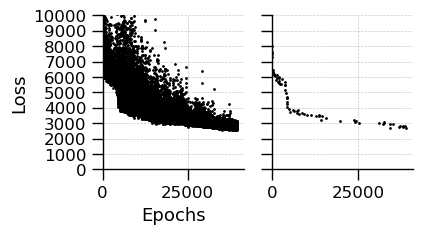

In [4]:
plot_losses(data_paths, xlim=(0, None), thresh=1500)

### 2D network, 300ms integration, *with* heterogeneity

In [5]:
data_paths = [
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:39:22.419915_run_000750',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:39:57.149671_run_000751',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:39:57.052713_run_000752',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:39:50.990124_run_000753',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:39:50.241391_run_000754',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:39:51.663809_run_000755',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:39:52.376865_run_000756',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:39:52.587371_run_000757',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:39:55.972538_run_000758',
    '2D_short_reverted_input_time_0.3_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:39:56.752124_run_000759',
]

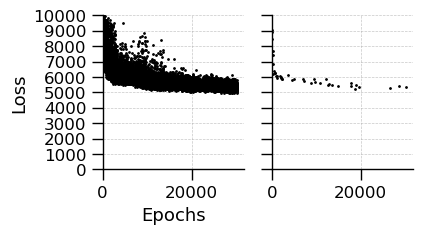

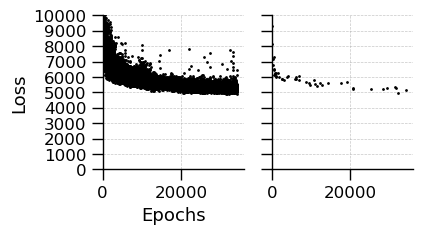

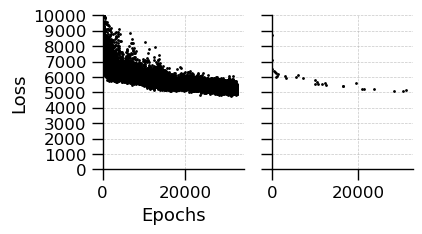

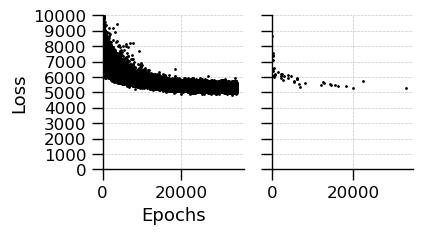

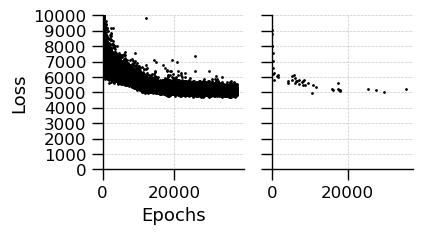

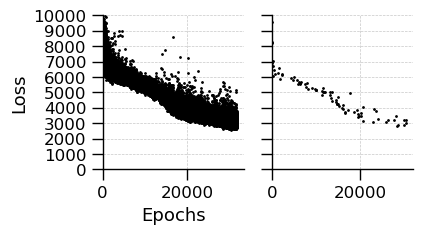

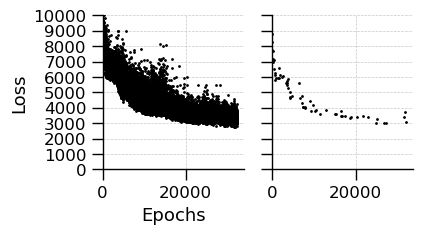

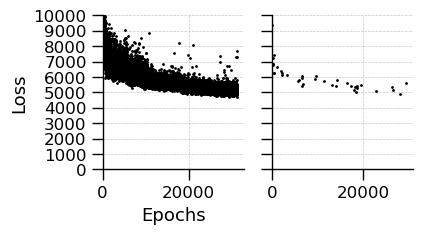

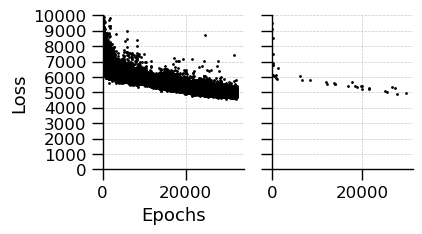

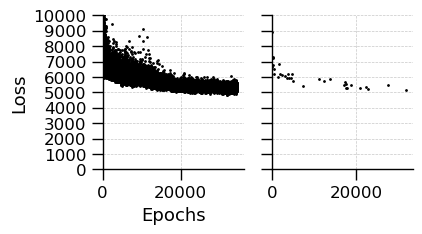

In [6]:
plot_losses(data_paths, xlim=(0, None), thresh=2000)

### 2D network, 1s integration, 300ms input, no heterogeneity

In [7]:
data_paths = [
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:43:52.531779_run_000860',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:43:52.531768_run_000861',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:43:52.571859_run_000862',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:43:53.616936_run_000863',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:43:53.616932_run_000864',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:43:52.076391_run_000865',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:43:52.554505_run_000866',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:43:52.554512_run_000867',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:43:52.554509_run_000868',
    '2D_long_reverted_time_1.0_inp_0.27_het_0_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:43:51.815465_run_000869',
]

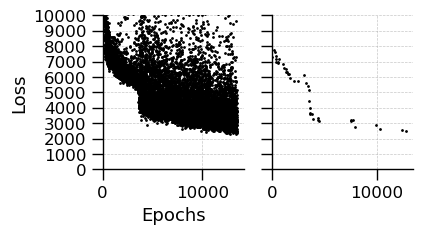

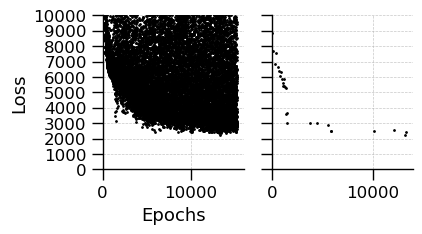

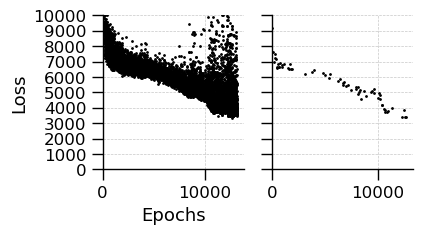

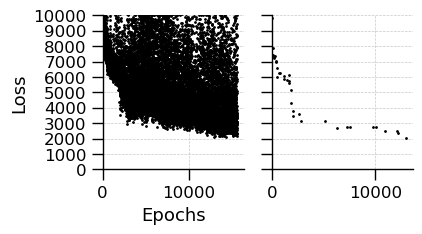

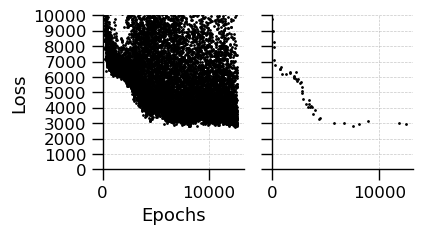

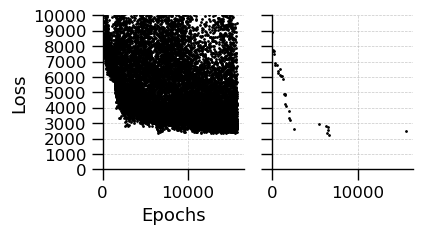

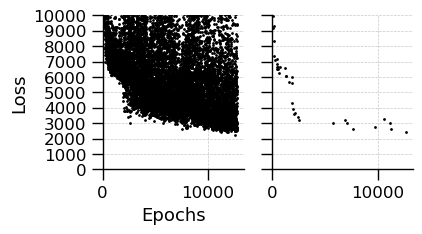

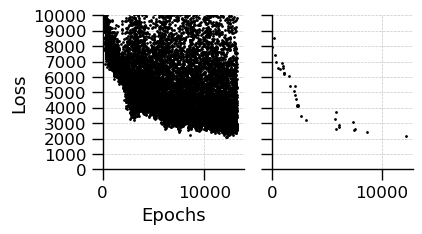

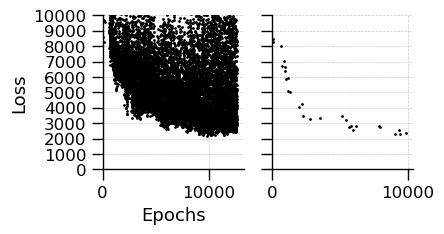

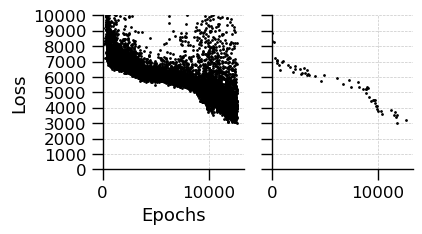

In [8]:
plot_losses(data_paths, xlim=(0, None), thresh=2000)

### 2D network, 1s integration, 300ms input, *with* heterogeneity

In [9]:
data_paths = [
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:40:52.909148_run_000800',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:40:53.471516_run_000801',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:40:50.790337_run_000802',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:40:52.210765_run_000803',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:40:52.210763_run_000804',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:40:52.210764_run_000805',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:40:52.070684_run_000806',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:40:52.070681_run_000807',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:40:52.070684_run_000808',
    '2D_long_reverted_time_1.0_inp_0.27_het_0.2_2D_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:40:52.070687_run_000809',
]

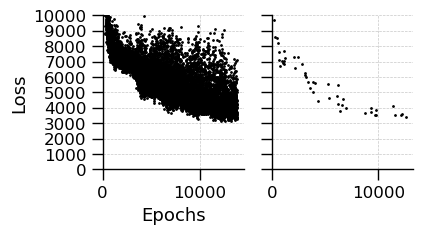

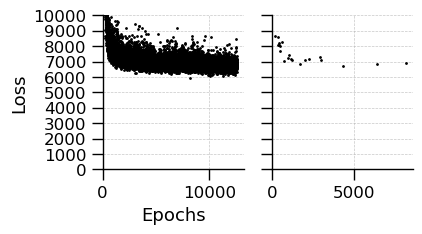

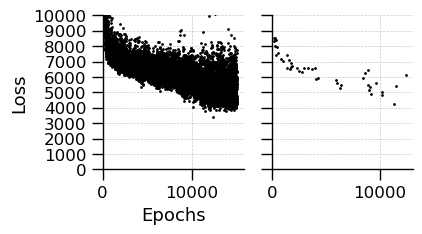

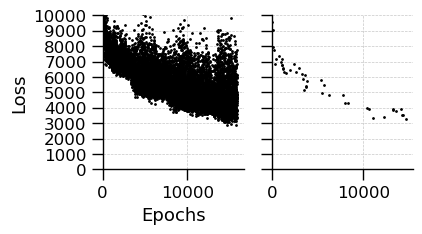

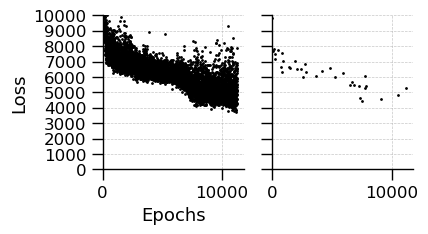

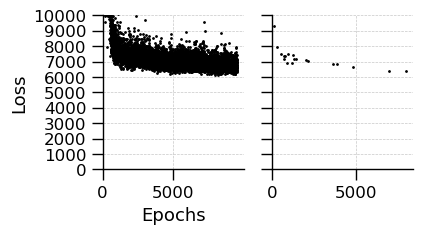

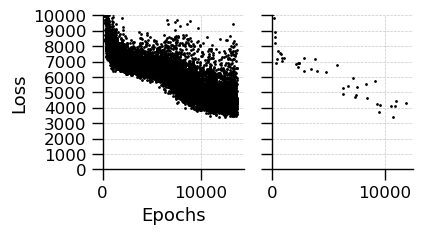

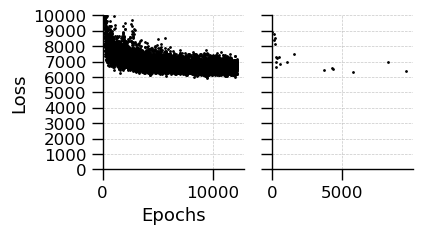

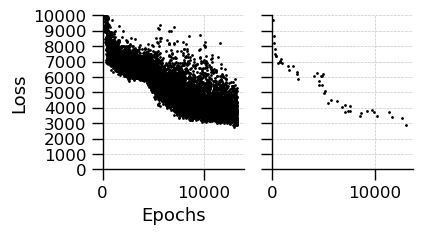

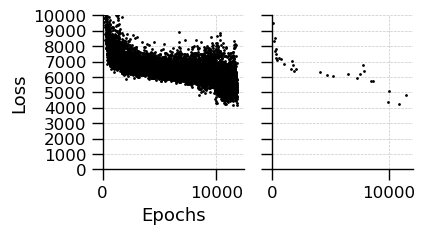

In [10]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

# 5 unit networks

### 5 unit network, 300s integration, 300ms input, *with* heterogeneity
I raised the minimum probably of getting an input at any timestep here from 0.1 to 0.25, so inputs are more frequent across all networks in this version of the task.

In [11]:
data_paths = [
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:59:58.750596_run_000640',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:59:58.965856_run_000641',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_01:00:05.422898_run_000642',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_01:00:05.422910_run_000643',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_01:00:05.422899_run_000644',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_01:00:05.422896_run_000645',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_01:00:05.422905_run_000646',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_01:00:06.209025_run_000647',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_01:00:06.209034_run_000648',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_01:00:06.209026_run_000649',
]

n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:59:58.965856_run_000641
n5_short_min_pactive_0p25_0.3_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_01:00:05.422899_run_000644


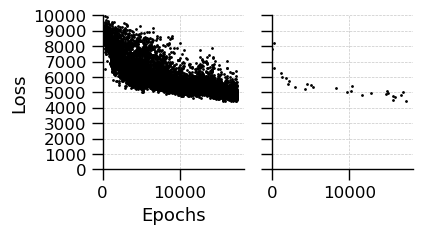

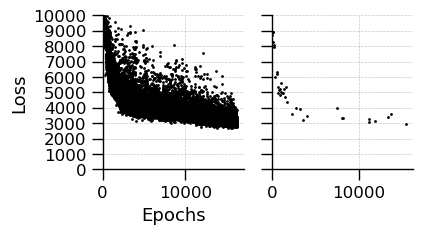

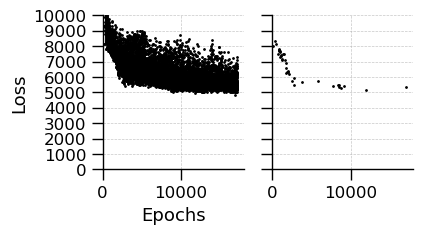

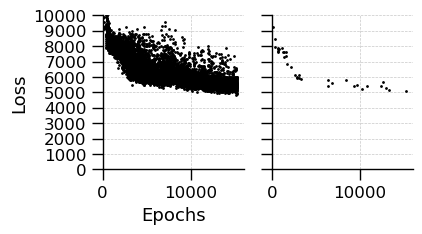

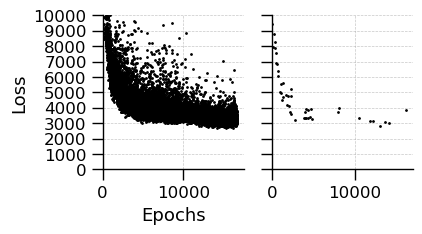

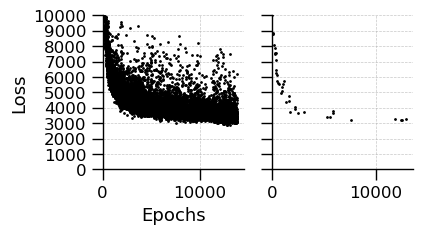

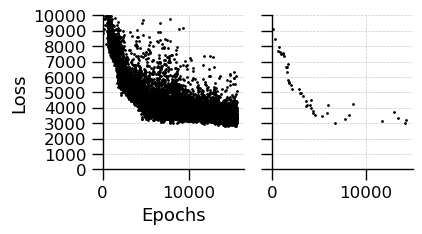

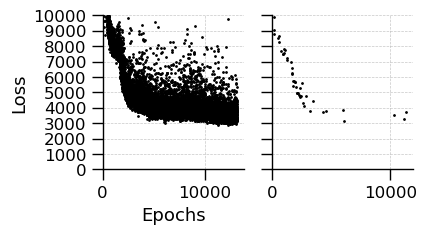

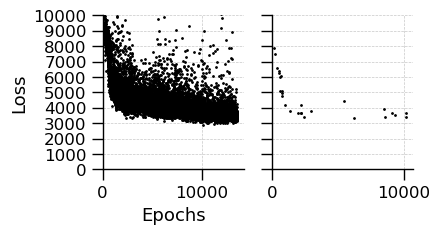

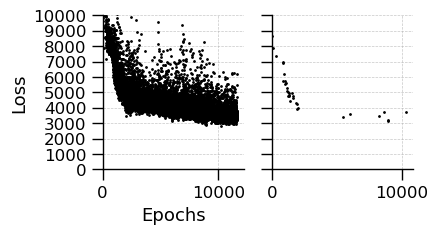

In [12]:
plot_losses(data_paths, xlim=(0, None), thresh=3000)

### 5 unit network, 300ms integration, 300ms input, no heterogeneity

In [13]:
data_paths = [
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:57:27.144748_run_000670',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:57:31.037464_run_000671',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:57:31.037462_run_000672',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:57:30.863035_run_000673',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:57:30.863039_run_000674',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:57:30.863037_run_000675',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:57:30.863034_run_000676',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:57:30.863036_run_000677',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:57:31.762208_run_000678',
    'n5_short_min_pactive_0p25_0.3_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:57:31.762178_run_000679',
]

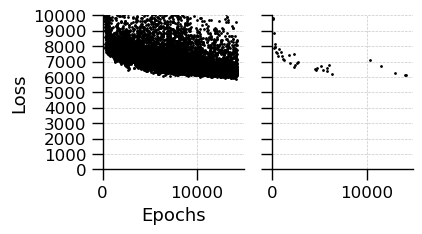

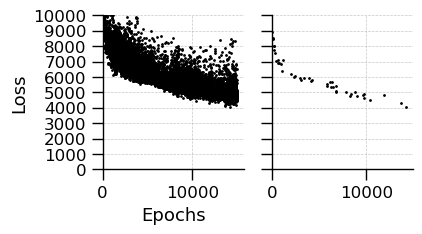

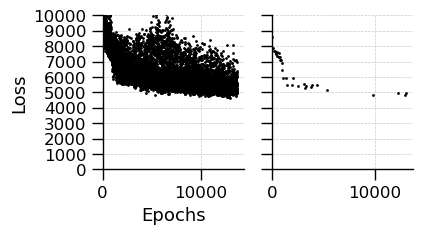

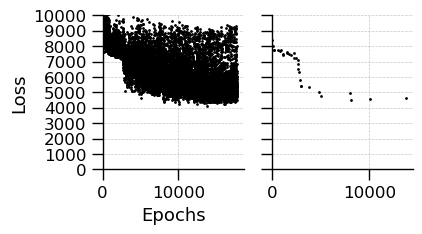

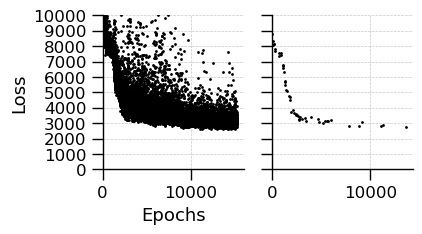

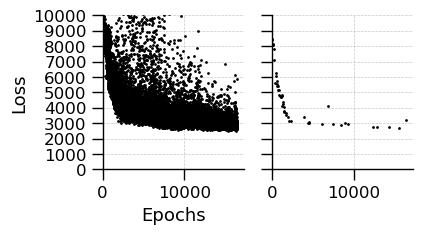

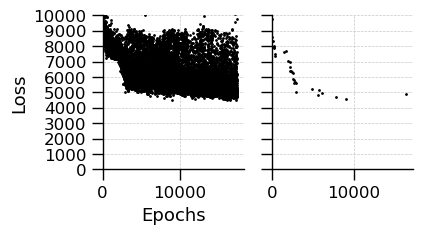

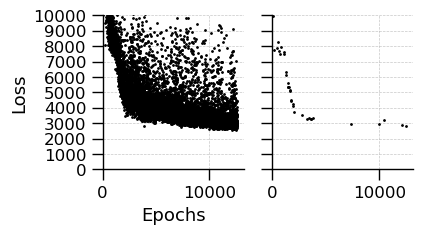

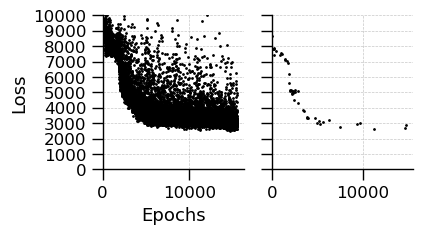

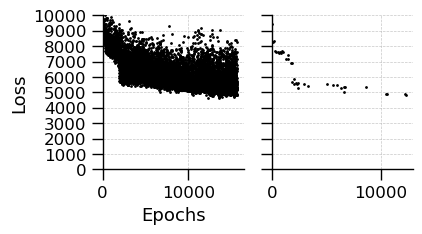

In [14]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [15]:
data_paths = [
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_00:58:27.683449_run_000680',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_00:58:27.571300_run_000681',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_00:58:27.733756_run_000682',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_00:58:27.677570_run_000683',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_00:58:32.274485_run_000684',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_00:58:32.274516_run_000685',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_00:58:32.274490_run_000686',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_00:58:34.869830_run_000687',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_00:58:34.869828_run_000688',
    'n5_long_min_pactive_0p25_1.0_inp_0.27_het_0_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_00:58:34.869832_run_000689',
]

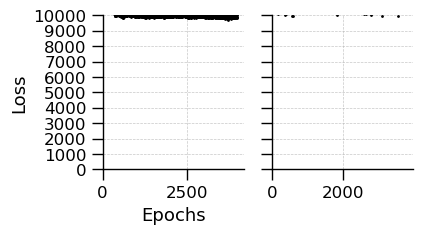

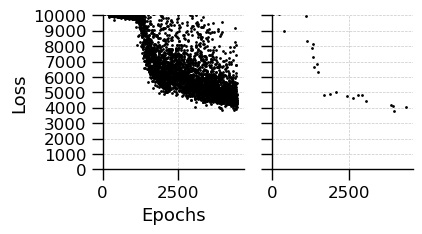

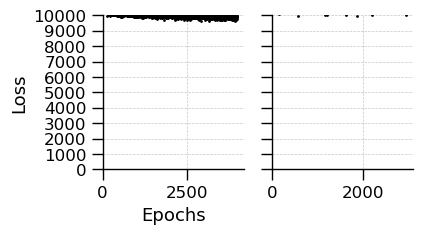

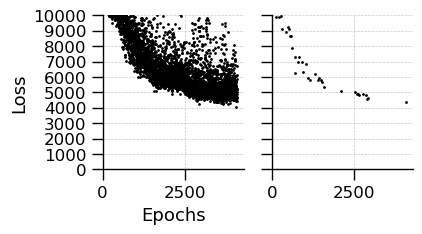

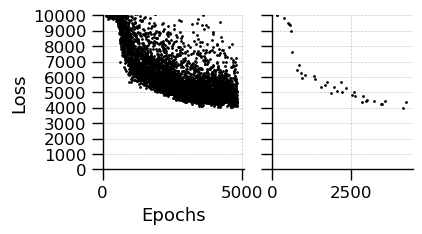

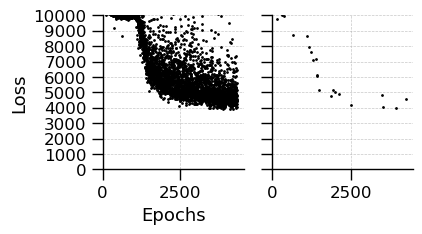

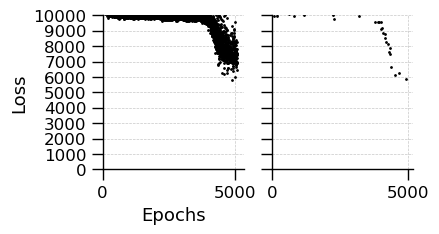

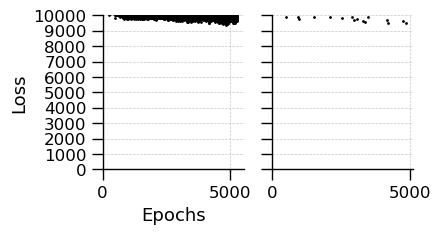

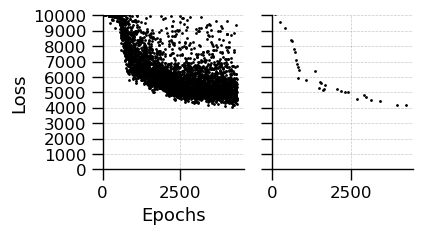

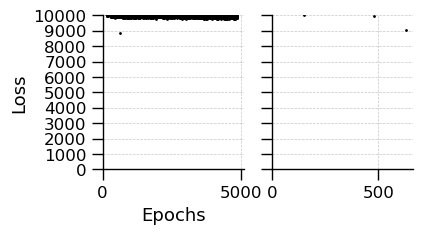

In [16]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)

In [17]:
data_paths = [
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8000_2025-12-08_01:01:09.648873_run_000690',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8001_2025-12-08_01:01:01.451109_run_000691',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8002_2025-12-08_01:01:01.451112_run_000692',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8003_2025-12-08_01:01:01.451093_run_000693',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8004_2025-12-08_01:00:59.224117_run_000694',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8005_2025-12-08_01:01:04.811582_run_000695',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8006_2025-12-08_01:01:04.811583_run_000696',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8007_2025-12-08_01:01:04.811586_run_000697',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8008_2025-12-08_01:01:04.811586_run_000698',
    'n5_short_min_pactive_0p25_1.0_inp_0.27_het_0.2_shift_10_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_8009_2025-12-08_01:01:03.658076_run_000699',
]

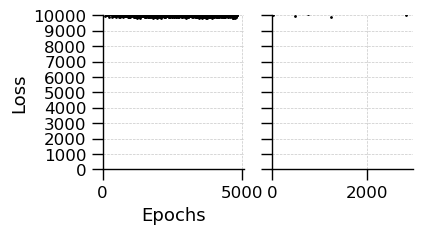

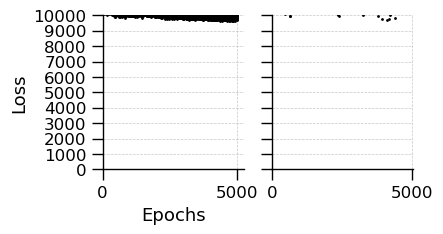

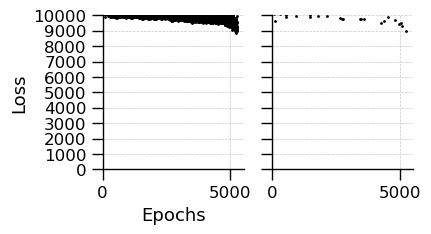

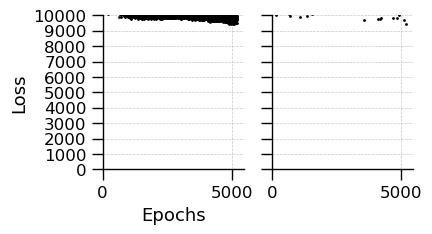

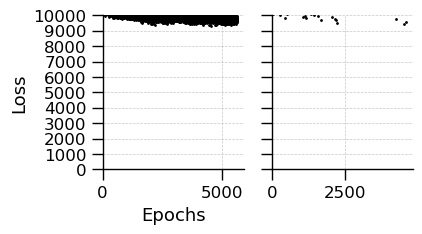

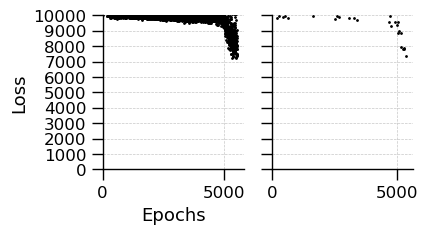

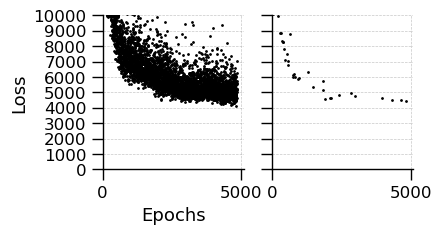

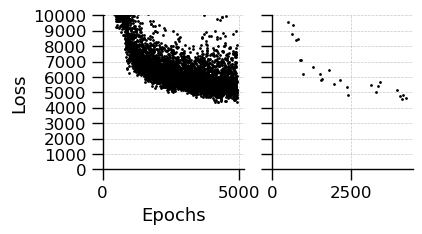

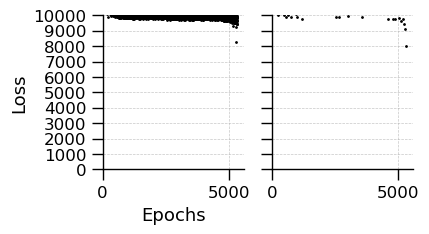

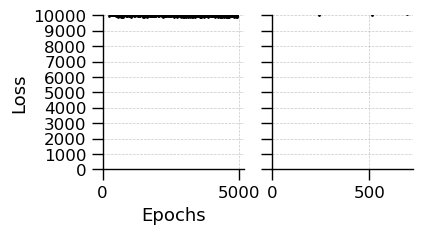

In [18]:
plot_losses(data_paths, xlim=(0, None), thresh=2500)